In [1]:
import numpy as np
import pandas as pd

In [2]:
# Prepare the dataset
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[base]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

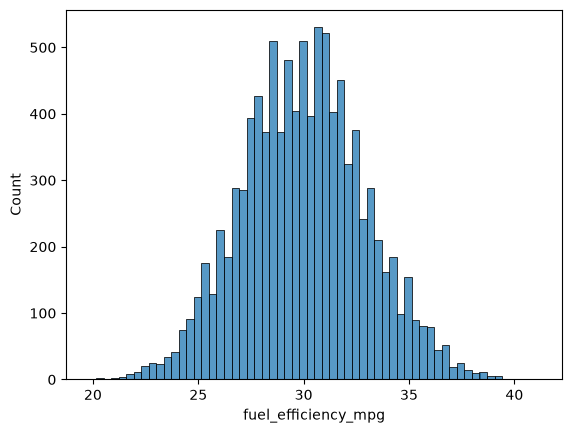

In [4]:
sns.histplot(df.fuel_efficiency_mpg)
# It doesn't have a long tail

In [5]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [6]:
df.horsepower.median()

np.float64(254.0)

In [7]:
# Shuffle the filtered dataset and create the split exactly as in the lecture:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [8]:
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def train_linear_regression(X, y):
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])

  XTX = X.T.dot(X)
  XTX_inv = np.linalg.inv(XTX)
  w_full = XTX_inv.dot(X.T).dot(y)
  
  return w_full[0], w_full[1:]

def rmse(y, y_pred):
  se = (y - y_pred) ** 2
  mse = se.mean()
  return np.sqrt(mse)

In [9]:
# Q3: try fill it with 0
def prepare_X(df):
  df = df.copy()
  df = df[features].fillna(0)
  X = df.values
  return X;

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = round(rmse(y_val, y_pred), 3)

score, y_pred, w0, w

(np.float64(2.205),
 array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
        30.75085098, 31.62912778], shape=(2000,)),
 np.float64(-153.88496188223104),
 array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]))

In [10]:
# Q3: try fill it with mean
train_horsepower_mean = df_train.horsepower.mean()

def prepare_X(df):
  df = df.copy()
  df = df[features]
  df.horsepower = df.horsepower.fillna(train_horsepower_mean)
  X = df.values
  return X;

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = round(rmse(y_val, y_pred), 3)

score, y_pred, w0, w

(np.float64(2.202),
 array([31.54288381, 29.92505122, 31.56459523, ..., 30.54408311,
        30.85701236, 31.55313717], shape=(2000,)),
 np.float64(-153.29645639182718),
 array([-0.00102386, -0.00648622, -0.00388828,  0.10197897]))

In [12]:
# Q4
def train_linear_regression_reg(X, y, r):
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])

  XTX = X.T.dot(X)
  XTX = XTX + r * np.eye(XTX.shape[0])

  XTX_inv = np.linalg.inv(XTX)
  w_full = XTX_inv.dot(X.T).dot(y)
  
  return w_full[0], w_full[1:]

In [13]:
def prepare_X(df):
  df = df.copy()
  df = df[features].fillna(0)
  X = df.values
  return X;

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
  X_train = prepare_X(df_train)
  w0, w = train_linear_regression_reg(X_train, y_train, r=r)

  X_val = prepare_X(df_val)
  y_pred = w0 + X_val.dot(w)
  score = rmse(y_val, y_pred)

  print(r, w0, score)

0 -153.88496188223104 2.205293194751098
0.01 -148.3092124404723 2.205827616672006
0.1 -111.83871039307081 2.2241432777850636
1 -32.331865964969374 2.349228888392786
5 -7.772852209978469 2.409380166599679
10 -3.987116416019025 2.4194698654732387
100 -0.4082196488463344 2.4292021380162367


In [14]:
# Q5
def split_data(seed):
  np.random.seed(seed)
  idx = np.arange(n)
  np.random.shuffle(idx)

  df_train = df.iloc[idx[:n_train]]
  df_val = df.iloc[idx[n_train:n_train + n_val]]
  df_test = df.iloc[idx[n_train + n_val:]]

  y_train = df_train.fuel_efficiency_mpg.values
  y_val = df_val.fuel_efficiency_mpg.values
  y_test = df_test.fuel_efficiency_mpg.values

  return df_train, df_val, df_test, y_train, y_val, y_test

def test_seed(seed):
  df_train, df_val, df_test, y_train, y_val, y_test = split_data(seed)

  X_train = prepare_X(df_train)
  w0, w = train_linear_regression(X_train, y_train)

  X_val = prepare_X(df_val)
  y_pred = w0 + X_val.dot(w)
  return rmse(y_val, y_pred)

scores = list(map(test_seed, np.arange(10)))
round(np.std(scores), 3), scores

(np.float64(0.029),
 [np.float64(2.2392041430461465),
  np.float64(2.2021128210838907),
  np.float64(2.163419778753095),
  np.float64(2.2043588768539144),
  np.float64(2.2018800943312926),
  np.float64(2.2457851509084974),
  np.float64(2.269721207952404),
  np.float64(2.190794599933433),
  np.float64(2.2166112016864443),
  np.float64(2.207036592817851)])

In [15]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(9)

df_full_train = pd.concat([df_train, df_val])
y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X(df_full_train)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score


np.float64(2.2358277471917636)